# はじめての深層学習 × PyTorch ハンズオン

## この会のゴール
- 深層学習についてザックリ理解する
- 深層学習に最も使用されるライブラリであるPyTorch で **データ準備 → モデル作成 → 学習 → 評価** の一連の流れを体験する

## 使うデータ
**FashionMNIST**:28×28ピクセルの白黒画像(服・靴・バッグなど10種類)
- 学習用 60,000枚 / テスト用 10,000枚

## 参考資料

-KIKAGAKU ディープラーニングの基礎 (おすすめ)
  https://free.kikagaku.ai/tutorial/basic_of_deep_learning


### 理論面
- 深層学習入門 ~基礎編~
  https://qiita.com/kuroitu/items/221e8c477ffdd0774b6b


### 実装面
- PyTorch 公式チュートリアル「Learn the Basics」
  https://pytorch.org/tutorials/beginner/basics/intro.html
- Quickstart
  https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
- FashionMNIST(Zalando Research)
  https://github.com/zalandoresearch/fashion-mnist


## 0. 深層学習とは?

**機械学習**:データから「入力 → 出力」の対応ルールをコンピュータに学ばせる技術
**深層学習**:そのルールを、何層も重ねた **ニューラルネットワーク** で表現する手法。 (人の脳のニューロンを模倣している)

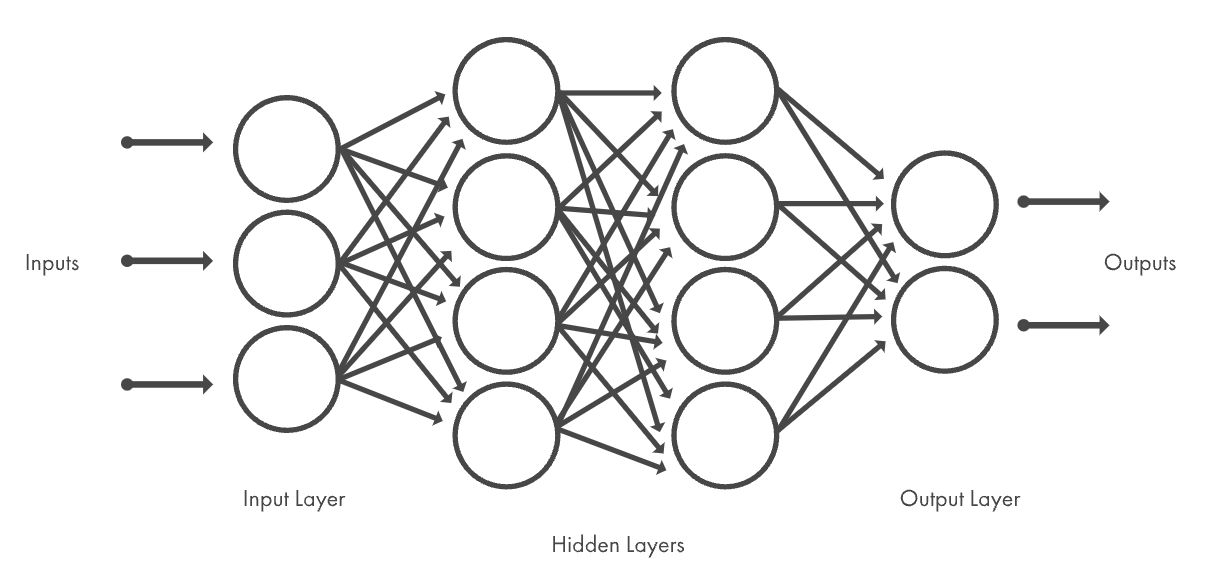
> https://zenn.dev/utokyo_aido/articles/619eba012b2660

### 学習の流れ
1. **予測する**:モデルに画像を入れて「これは何か」を当てさせる(順伝播)
2. **間違いを測る**:予測と正解のズレを数値化 (損失関数：Loss Function) する(**損失 / loss**)
3. **直す**:ズレが小さくなる方向にモデルのパラメータを少し動かす(**勾配降下法**)
4. これを何度も繰り返す



In [3]:
!pip install torch 
!pip install scikit-learn
!pip install matplotlib


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression

torch.manual_seed(42)   # 結果の再現性のため乱数を固定
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch version:", torch.__version__, "/ device:", device)

PyTorch version: 2.11.0+cu128 / device: cuda


## 1. 勾配降下法:深層学習の手法な学習方法

モデルには **パラメータ**(重み)があり、学習とは「損失が最小になるパラメータを探すこと」です。

### 簡単な例
パラメータ $w$ が1個だけで、損失が $L(w) = (w - 3)^2$ だとします。
答えは明らかに $w = 3$(このとき損失は0)ですが、コンピュータはこれを「知らない」ものとします。

### 手がかりは「傾き」= 微分
$\frac{dL}{dw} = 2(w - 3)$

- 傾きが **正** → $w$ を **減らす** と損失が下がる
- 傾きが **負** → $w$ を **増やす** と損失が下がる

つまり、**傾きと逆向きに少し動かせばよい** ということです。
深層学習では、膨大なパラメータ・複雑な非線形関数を組合わせるため、微分 = 0のように、解析的に最適なパラメータを求めることはできません。そのため勾配降下法のようなアルゴリズムにより、パラメータを計算します。

### 更新式
$$
w \leftarrow w - \eta \cdot \frac{dL}{dw}
$$

$\eta$(イータ)は **学習率**、とよび、一度ど更新でどの程度パラメータを動かすか決めるパラメータです。学習率が高い (1 ~0.1)と学習速度は速いですが、最適なパラメータ荷駄とりつきにくい・大規模なモデルでは学習がうまくいかないなどの問題が出てきます。大規模なモデルでは1e-5、1e-6などの値が設定されたり、学習中に学習率を変更することもあります。 (スケジューラー)

> 実際のモデルにはパラメータが数千〜数億個あります。
> そのすべてについて手で微分するのは不可能なので、
> PyTorch の **自動微分 (autograd)** が勾配を計算してくれます。

In [5]:
# テンソルの基本 torchで扱うパラメータの形式
t = torch.tensor([[1.0, 2.0], [3.0, 4.0]])
print(t, t.shape, t.dtype)

# 自動微分
x = torch.tensor(2.0, requires_grad=True)
y = x**2 + 3 * x
y.backward()
print("dy/dx =", x.grad.item())   # → 7.0

tensor([[1., 2.],
        [3., 4.]]) torch.Size([2, 2]) torch.float32
dy/dx = 7.0


## 2. データの確認
pandas でデータの中身を確認します。
注意:scikit-learn 版では **0 = 悪性 (malignant)、1 = 良性 (benign)** です。

In [6]:
data = load_breast_cancer(as_frame=True)
df = data.frame
print("形状:", df.shape)            # (569, 31) = 30特徴量 + target
display(df.head())

print("\nクラスの内訳:")
print(df["target"].map({0: "malignant", 1: "benign"}).value_counts())

形状: (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0



クラスの内訳:
target
benign       357
malignant    212
Name: count, dtype: int64


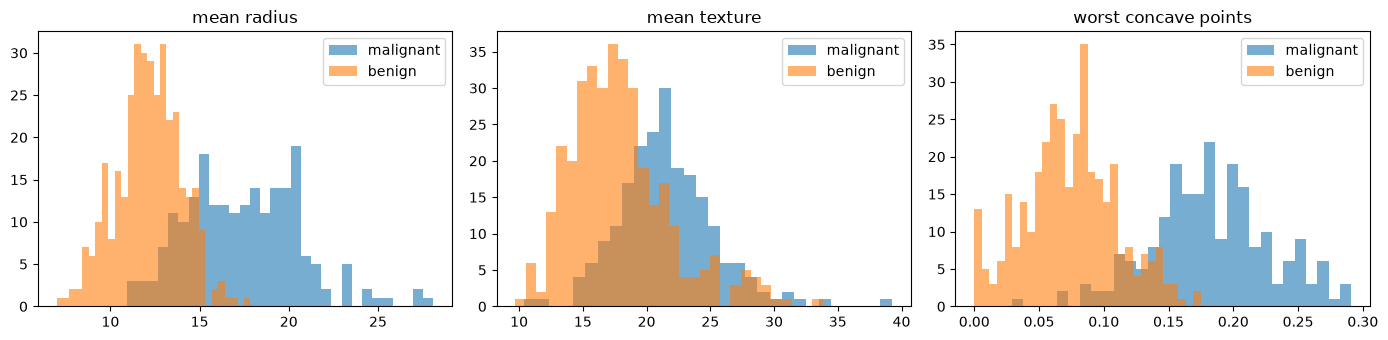

,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.1100
mean texture,19.289649,4.301036,9.71000,39.2800
mean perimeter,91.969033,24.298981,43.79000,188.5000
mean area,654.889104,351.914129,143.50000,2501.0000
mean smoothness,0.096360,0.014064,0.05263,0.1634
mean compactness,0.104341,0.052813,0.01938,0.3454
mean concavity,0.088799,0.079720,0.00000,0.4268
mean concave points,0.048919,0.038803,0.00000,0.2012


In [7]:
# 特徴量の例:悪性・良性で分布が違うか?
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, col in zip(axes, ["mean radius", "mean texture", "worst concave points"]):
    for label, name in [(0, "malignant"), (1, "benign")]:
        ax.hist(df.loc[df["target"] == label, col], bins=30, alpha=0.6, label=name)
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

# 特徴量ごとにスケールが大きく違う点にも注目
display(df.drop(columns="target").describe().T[["mean", "std", "min", "max"]].head(8))

## 3. 前処理

### (1) 学習用とテスト用に分ける
モデルが「初めて見るデータ」でどれだけ当たるかを測るため、テスト用データは学習に使いません。

### (2) 標準化(平均0・標準偏差1にそろえる)
`mean area` は数百、`mean smoothness` は0.1程度と、特徴量のスケールがバラバラです。
スケールがそろっていないと、ニューラルネットの学習は不安定になりやすくなります。

> **重要**:標準化のパラメータ(平均・標準偏差)は **学習データだけ** から計算します。
> テストデータの情報を使うと「カンニング」(データリーク)になります。

In [8]:
X = df.drop(columns="target").values
y = df["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 学習データで平均・分散を計算して変換
X_test = scaler.transform(X_test)         # テストデータは変換のみ

print("train:", X_train.shape, "test:", X_test.shape)

train: (455, 30) test: (114, 30)


## 4. PyTorch のデータ形式にする
Pytorchで学習する際に必要な形にそろえてあげる。 (現時点ではおまじないみたいなものだと)

- NumPy 配列 → **テンソル** に変換
- `TensorDataset`:特徴量とラベルを組にする
- `DataLoader`:**ミニバッチ** に分けて、シャッフルしながら順に渡す

In [9]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)  # [N] → [N, 1]
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_ds = TensorDataset(X_train_t, y_train_t)
test_ds = TensorDataset(X_test_t, y_test_t)

batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=batch_size)

xb, yb = next(iter(train_loader))
print("特徴量バッチ:", xb.shape, "/ ラベルバッチ:", yb.shape)   # [32, 30], [32, 1]

特徴量バッチ: torch.Size([32, 30]) / ラベルバッチ: torch.Size([32, 1])


## 5. モデルを定義する

**30個の特徴量 → 32 → 16 → 1個の出力(悪性/良性のスコア)**

| 部品 | 役割 |
|---|---|
| `nn.Linear` | 重み付きの足し算(**学習されるパラメータ**) |
| `nn.ReLU` | 活性化関数。非線形性を加え、複雑な境界を表現できるようにする |

最後の出力は **ロジット**(確率になる前の生のスコア)です。
`sigmoid` 関数で0~1の確率になります。

In [10]:
class TabularNet(nn.Module): # 作成した深層学習の名前
    def __init__(self, n_features): # ネットワークの初期構造
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
        )
        
    def forward(self, x): # 学習する際に入力した値をどのように処理するか
        return self.net(x)   # ロジットを返す
        

model = TabularNet(n_features=X_train.shape[1]).to(device)
print(model)
print("パラメータ数:", sum(p.numel() for p in model.parameters()))

TabularNet(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=1, bias=True)
  )
)
パラメータ数: 1537


## 6. 損失関数と最適化手法

- **損失関数**:2値分類なので `nn.BCEWithLogitsLoss`(ロジットを受け取る二値交差エントロピー)
- **オプティマイザ**:`Adam`(パラメータの移動幅を自動調整してくれる、実務でよく使われる手法)
- **学習率**:1回にパラメータを動かす幅

### 効率的に学習する仕組み
大量のデータをもとに一度にパラメータを更新することはPCの性能上難しいことが多いです。そのためデータセットをバッチという細かい単位に分割して、バッチごとにパラメータ更新を繰り替えす方法がほとんどすべての深層学習において実施されます。

- **バッチ**:一度に処理するデータのまとまり(今回は32件)
- **エポック**:学習データを全部1周すること

In [11]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

## 7. 学習ループ

| ステップ | コード |
|---|---|
| ① 予測する | `pred = model(X)` |
| ② 間違いを測る | `loss = loss_fn(pred, y)` |
| ③ 勾配を計算する | `loss.backward()` |
| ④ パラメータを更新する | `optimizer.step()` |
| (勾配をリセット) | `optimizer.zero_grad()` |

In [12]:
def train_one_epoch(loader, model, loss_fn, optimizer):
    model.train()
    total = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        pred = model(X)              # ① 予測
        loss = loss_fn(pred, y)      # ② 損失
        loss.backward()              # ③ 勾配
        optimizer.step()             # ④ 更新
        optimizer.zero_grad()
        total += loss.item() * len(X)
    return total / len(loader.dataset)


def evaluate(loader, model, loss_fn):
    model.eval()
    total, correct = 0.0, 0
    with torch.no_grad(): #予測時には勾配を計算しない
        for X, y in loader: #データローダーからデータを取り出す
            X, y = X.to(device), y.to(device) # GPUを使用できる場合はGPUメモリ上にデータを移動
            logits = model(X) # 予測確率の直前の値 (シグモイド関数に入力する直前の値)
            total += loss_fn(logits, y).item() * len(X) # 損失関数を計算
            pred_label = (torch.sigmoid(logits) >= 0.5).float() # 予測確率0.5以上で陽性と判定
            correct += (pred_label == y).sum().item()
    n = len(loader.dataset)
    return total / n, correct / n

In [13]:
epochs = 100
history = {"train_loss": [], "test_loss": [], "test_acc": []}

for epoch in range(1, epochs + 1):
    tr_loss = train_one_epoch(train_loader, model, loss_fn, optimizer)
    te_loss, te_acc = evaluate(test_loader, model, loss_fn)
    history["train_loss"].append(tr_loss)
    history["test_loss"].append(te_loss)
    history["test_acc"].append(te_acc)
    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | train loss {tr_loss:.4f} | "
              f"test loss {te_loss:.4f} | test acc {te_acc * 100:.1f}%")

Epoch  10 | train loss 0.0910 | test loss 0.1165 | test acc 95.6%
Epoch  20 | train loss 0.0475 | test loss 0.0935 | test acc 96.5%
Epoch  30 | train loss 0.0346 | test loss 0.0875 | test acc 95.6%
Epoch  40 | train loss 0.0254 | test loss 0.0866 | test acc 95.6%
Epoch  50 | train loss 0.0185 | test loss 0.0874 | test acc 96.5%
Epoch  60 | train loss 0.0137 | test loss 0.0872 | test acc 96.5%
Epoch  70 | train loss 0.0102 | test loss 0.0901 | test acc 96.5%
Epoch  80 | train loss 0.0067 | test loss 0.0969 | test acc 96.5%
Epoch  90 | train loss 0.0040 | test loss 0.0997 | test acc 96.5%
Epoch 100 | train loss 0.0028 | test loss 0.1022 | test acc 96.5%


## 8. 結果を確認する

### 学習曲線
train loss は下がり続けるのに test loss が途中から上がる場合、それは **過学習** のサインです。

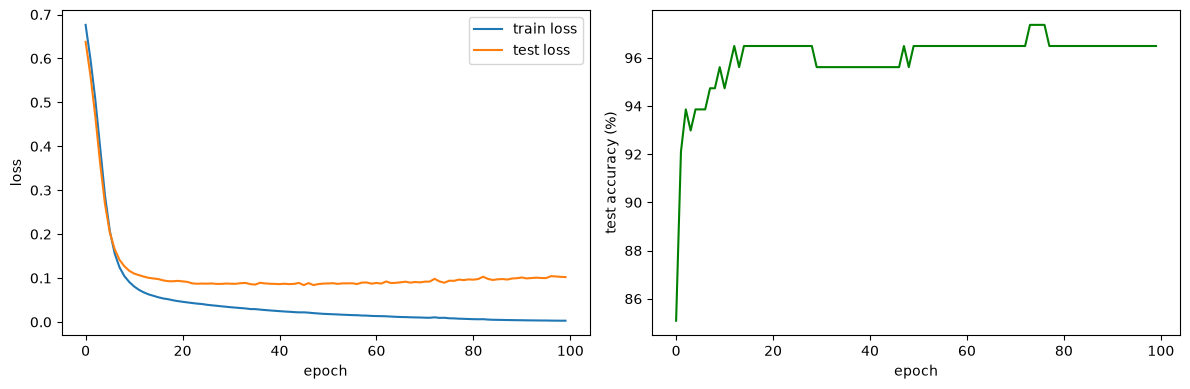

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train loss")
axes[0].plot(history["test_loss"], label="test loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend()
axes[1].plot([a * 100 for a in history["test_acc"]], color="green")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("test accuracy (%)")
plt.tight_layout(); plt.show()

### 混同行列と各指標
医療の文脈では、正解率だけでなく **どちらの間違いか** が重要です。
- 悪性を良性と見逃す(偽陰性)
- 良性を悪性と判定する(偽陽性)

In [15]:
model.eval()
with torch.no_grad():
    probs = torch.sigmoid(model(X_test_t.to(device))).cpu().numpy().ravel()
y_pred_nn = (probs >= 0.5).astype(int)

print("NN Accuracy:", accuracy_score(y_test, y_pred_nn))
print("混同行列(行=正解, 列=予測, 0=malignant, 1=benign):")
print(confusion_matrix(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn, target_names=["malignant", "benign"]))

NN Accuracy: 0.9649122807017544
混同行列(行=正解, 列=予測, 0=malignant, 1=benign):
[[41  1]
 [ 3 69]]
              precision    recall  f1-score   support

   malignant       0.93      0.98      0.95        42
      benign       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



### 自動微分で勾配降下法を回してみる
$w = 0$ からスタートして、$L(w) = (w-3)^2$ を最小にする $w$ を探します。

step  0 | w = 0.0000 | loss = 9.0000
step  5 | w = 2.0170 | loss = 0.9664
step 10 | w = 2.6779 | loss = 0.1038
step 15 | w = 2.8944 | loss = 0.0111
step 20 | w = 2.9654 | loss = 0.0012
step 25 | w = 2.9887 | loss = 0.0001
最終的な w = 2.9963


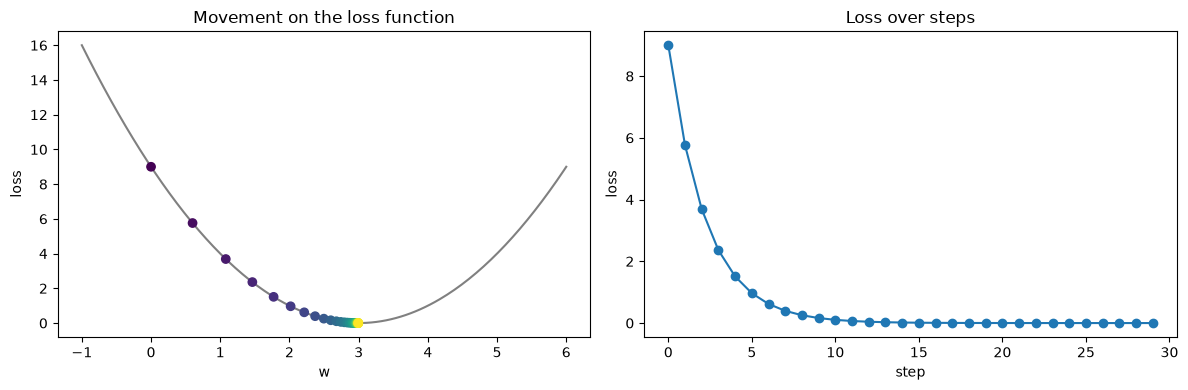

In [16]:
w = torch.tensor(0.0, requires_grad=True)   # パラメータ(初期値0)
lr = 0.1                                     # 学習率
w_hist, loss_hist = [], []

for step in range(30):
    loss = (w - 3) ** 2          # ① 損失を計算
    loss.backward()              # ② 勾配 dL/dw を自動計算

    w_hist.append(w.item())
    loss_hist.append(loss.item())

    with torch.no_grad():        # 更新そのものは微分の対象にしない
        w -= lr * w.grad         # ③ 傾きと逆向きに一歩進む
    w.grad.zero_()               # ④ 勾配をリセット(PyTorchは勾配を足し込むため)

    if step % 5 == 0:
        print(f"step {step:2d} | w = {w_hist[-1]:.4f} | loss = {loss_hist[-1]:.4f}")

print(f"最終的な w = {w.item():.4f}")

# 可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ws = np.linspace(-1, 6, 200)
axes[0].plot(ws, (ws - 3) ** 2, color="gray")
axes[0].scatter(w_hist, loss_hist, c=range(len(w_hist)), cmap="viridis", zorder=3)
axes[0].set_xlabel("w"); axes[0].set_ylabel("loss"); axes[0].set_title("Movement on the loss function")
axes[1].plot(loss_hist, marker="o")
axes[1].set_xlabel("step"); axes[1].set_ylabel("loss"); axes[1].set_title("Loss over steps")
plt.tight_layout(); plt.show()

## ここまでのまとめ

- 深層学習における学習は、勾配降下法などの最適化手法を用いた

# 第2部:分子を「文章」として読む ― Attention・Transformer・化学言語モデル

第1部では、人が計算した **30個の数値(記述子)** で腫瘍を表しました。
しかし、化合物ならどうでしょう? どの記述子を使うかを人が決めるのは大変です。

**アイデア**:分子は SMILES という「文字列」で書ける → 文章を読むAIに、分子を読ませればよい

| 自然言語 | 化学 |
|---|---|
| 文章 `I like aspirin` | SMILES `CC(=O)Oc1ccccc1C(=O)O` |
| 単語 | 原子・結合・環の番号 |
| 文法 | 価数・環の閉じ方などのルール |

この第2部の流れ:
**トークン化 → 埋め込み → Attention → Transformer → 事前学習済みモデルのデモ**

> ⚠️ このあとのデモでは、Hugging Face からモデル(合計でおよそ数百MB)をダウンロードします。（この部分の実行は飛ばします。）

In [17]:
!pip install transformers sentencepiece


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
import re, math
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(0)

## 1. トークン化:SMILES をどこで区切るか

コンピュータは文字列を直接は扱えません。まず **トークン**(意味のある最小単位)に区切ります。
1文字ずつ区切ると、どんな問題が起きるでしょうか?

In [19]:
aspirin = "CC(=O)Oc1ccccc1C(=O)O"
print("1文字ずつ:", list("ClCCBr"))   # Cl(塩素)と Br(臭素)が壊れる!

# 化学的に意味のある単位で区切る正規表現
# (Schwaller et al., Molecular Transformer で使われた方式)
SMILES_REGEX = r"(\[[^\]]+]|Br?|Cl?|N|O|S|P|F|I|b|c|n|o|s|p|\(|\)|\.|=|#|-|\+|\\|\/|:|~|@|\?|>|\*|\$|%[0-9]{2}|[0-9])"

def tokenize(smiles):
    return re.findall(SMILES_REGEX, smiles)

print("正規表現:", tokenize("ClCCBr"))
print("立体化学:", tokenize("C[C@@H](N)C(=O)O"))   # [C@@H] を1トークンとして扱える

tokens = tokenize(aspirin)
vocab = {t: i for i, t in enumerate(sorted(set(tokens)))}   # 語彙(トークン→ID)
ids = torch.tensor([vocab[t] for t in tokens])
print("語彙:", vocab)
print("ID列:", ids.tolist())

1文字ずつ: ['C', 'l', 'C', 'C', 'B', 'r']
正規表現: ['Cl', 'C', 'C', 'Br']
立体化学: ['C', '[C@@H]', '(', 'N', ')', 'C', '(', '=', 'O', ')', 'O']
語彙: {'(': 0, ')': 1, '1': 2, '=': 3, 'C': 4, 'O': 5, 'c': 6}
ID列: [4, 4, 0, 3, 5, 1, 5, 6, 2, 6, 6, 6, 6, 6, 2, 4, 0, 3, 5, 1, 5]


## 2. 埋め込み(Embedding):ID をベクトルにする

ID は単なる番号なので、「C と c が似ている」といった情報を持ちません。
そこで `nn.Embedding` を使い、各トークンを **学習可能なベクトル** に変換します。
中身は第1部の `nn.Linear` と同じく、学習で更新されるパラメータです。

In [20]:
d_model = 16                                  # ベクトルの次元
embedding = nn.Embedding(len(vocab), d_model)
X = embedding(ids).detach()                   # [トークン数, 次元]
print("埋め込みの形状:", X.shape)              # [21, 16]

埋め込みの形状: torch.Size([21, 16])


In [21]:
print("ID が 0 の埋め込み")
print(X[0])

ID が 0 の埋め込み
tensor([-0.5692,  0.9200,  1.1108,  1.2899, -1.4782,  2.5672, -0.4731,  0.3356,
        -1.6293, -0.5497, -0.4798, -0.4997, -1.0670,  1.1149, -0.1407,  0.8058])


## 3. Attention:どのトークンに「注目」するか

分子の性質は、**離れた位置の原子同士の関係** で決まることがよくあります
(例:アスピリンのエステル部分とカルボン酸部分)。
Attention は、各トークンが **他のすべてのトークンをどれだけ参照するか** を計算する仕組みです。

### 図書館の検索にたとえると
| 名前 | たとえ | 役割 |
|---|---|---|
| **Query (Q)** | 検索したいこと | 「私はどんな情報がほしいか」 |
| **Key (K)** | 本の索引 | 「私はこんな情報を持っている」 |
| **Value (V)** | 本の中身 | 実際に受け渡す情報 |

$$
\text{Attention}(Q,K,V) = \text{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

> Attentionのイメージ
>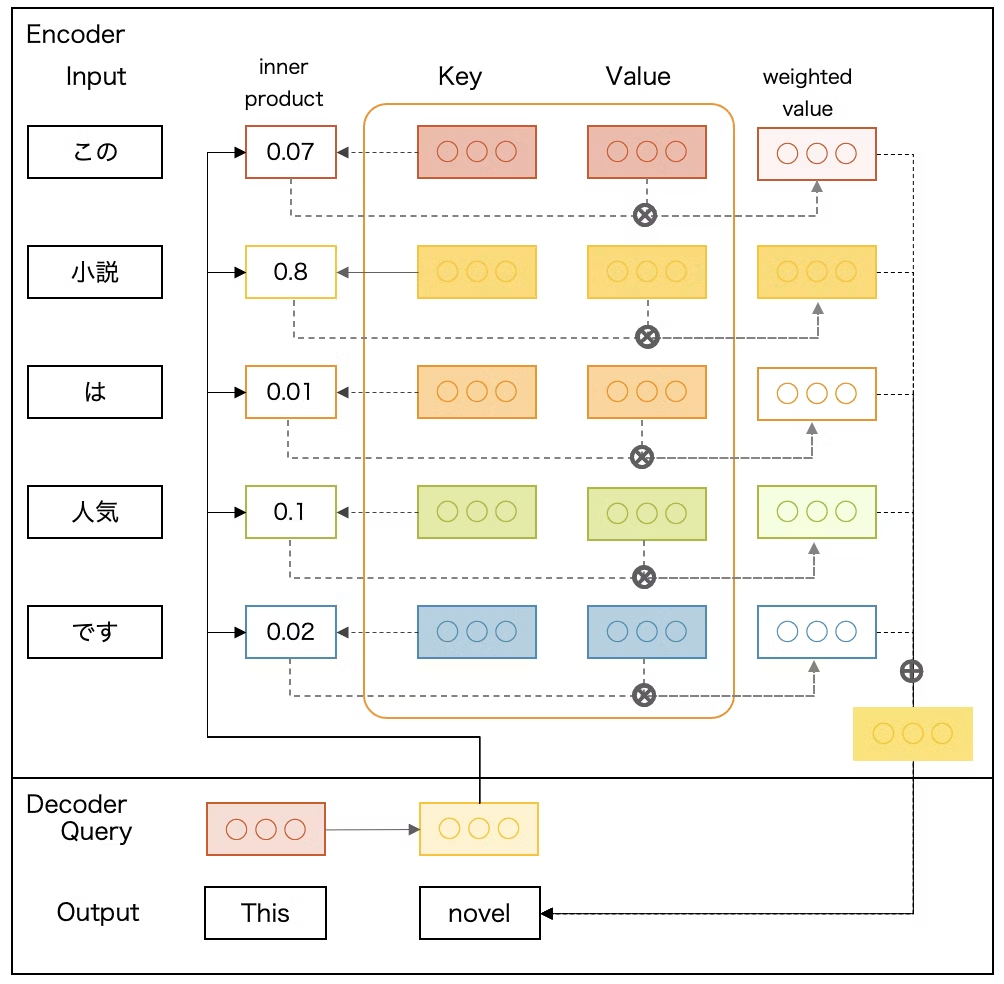
>参考：[リンク](https://qiita.com/ps010/items/0bb2931b666fa602d0fc)

1. $QK^\top$:Query と Key の **類似度**(内積)
2. $\sqrt{d_k}$ で割る:値が大きくなりすぎないように調整する
3. softmax:足して1になる **注目度(重み)** に変換する
4. 重みで Value の **重み付き平均** を取る

→ 中身は **行列積と softmax だけ** です。

出力: torch.Size([21, 16]) / 各行の重みの合計: tensor([1.0000, 1.0000, 1.0000])
PyTorch 組み込みと一致: True


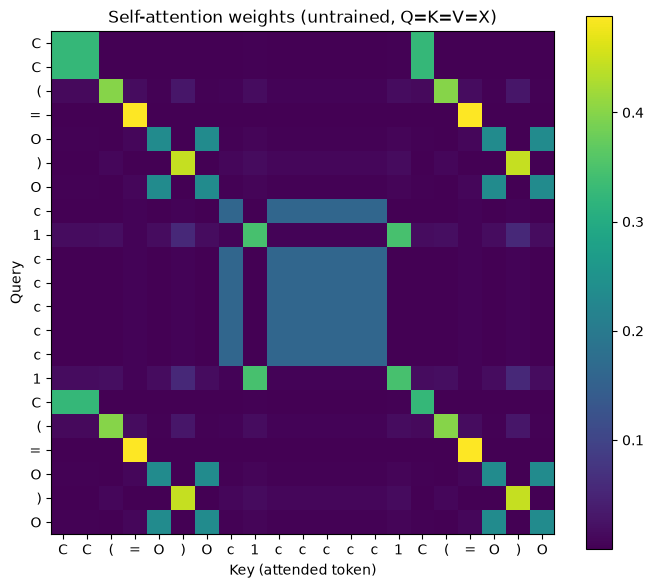

In [22]:
def attention(Q, K, V, mask=None):
    d_k = Q.size(-1)
    scores = Q @ K.transpose(-2, -1) / math.sqrt(d_k)       # ① 類似度
    if mask is not None:
        scores = scores.masked_fill(mask == 0, float("-inf"))
    weights = torch.softmax(scores, dim=-1)                 # ② 注目度(各行の合計は1)
    return weights @ V, weights                             # ③ 重み付き平均

out, w = attention(X, X, X)
print("出力:", out.shape, "/ 各行の重みの合計:", w.sum(-1)[:3])

# PyTorch 組み込み関数と結果が一致することを確認
ref = F.scaled_dot_product_attention(X[None], X[None], X[None])[0]
print("PyTorch 組み込みと一致:", torch.allclose(out, ref, atol=1e-6))

# 可視化
plt.figure(figsize=(7, 6))
plt.imshow(w, cmap="viridis")
plt.xticks(range(len(tokens)), tokens); plt.yticks(range(len(tokens)), tokens)
plt.xlabel("Key (attended token)"); plt.ylabel("Query")
plt.title("Self-attention weights (untrained, Q=K=V=X)")
plt.colorbar(); plt.tight_layout(); plt.show()

### 未学習のAttention
学習前のため、ここでは「**同じトークン同士**(例:O と O)が強く注目し合う」だけです。
同じトークンは同じベクトルを持つので、内積が大きくなるからです。

実際のモデルでは、Q・K・V を作る前に **学習される重み** $W_Q, W_K, W_V$ を掛けます。
これにより、「カルボニル炭素は隣の酸素に注目する」といった **化学的に意味のある注目の仕方** を、学習を通じて獲得します。

In [23]:
# 学習される重みを入れた Attention
W_q = nn.Linear(d_model, d_model, bias=False)
W_k = nn.Linear(d_model, d_model, bias=False)
W_v = nn.Linear(d_model, d_model, bias=False)
with torch.no_grad():
    out2, _ = attention(W_q(X), W_k(X), W_v(X))
print(out2.shape)

# 「先を見てはいけない」マスク(GPT 型のモデルが使う)
L = len(tokens)
causal_mask = torch.tril(torch.ones(L, L))
_, w_causal = attention(X, X, X, mask=causal_mask)
print("因果マスク付きの重み(左上):\n", w_causal[:4, :5].round(decimals=2))

torch.Size([21, 16])
因果マスク付きの重み(左上):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000, 0.0000, 0.0000],
        [0.0300, 0.0300, 0.9400, 0.0000, 0.0000],
        [0.0000, 0.0000, 0.0000, 1.0000, 0.0000]])


## 4. Transformer:Attentionを使用した代表的なネットワーク

Transformer ブロック = **Attention** + 第1部で使った **全結合層(Linear+活性化関数)** + 学習を安定させる工夫
> Transformerを提案した論文：Attenrion is all you need は2026年9月時点で27万回引用されており、LLMの基盤となっている。

| 部品 | 役割 |
|---|---|
| **Multi-Head Attention** | Attention を複数並列に計算する(例:「結合」を見るヘッド、「官能基」を見るヘッド) |
| **位置エンコーディング** | Attention そのものは語順を区別できないので、位置の情報を足す |
| **残差接続 + LayerNorm** | 層を深く重ねても学習が崩れないようにする |
| **Feed-Forward(FFN)** | 各トークンを個別に変換する(第1部の MLP と同じ) |

### Transformer の3つの型(このあと紹介するモデルの地図)
| 型 | Attention の特徴 | 得意なこと | 代表例 |
|---|---|---|---|
| **Encoder のみ**(BERT 型) | 前後すべてを見る | 理解・特徴抽出・物性予測 | ChemBERTa, MoLFormer, ESM-2 |
| **Encoder-Decoder**(T5/BART 型) | 入力を読んでから別の系列を書く | 翻訳(分子↔文章、反応予測) | MolT5, Molecular Transformer |
| **Decoder のみ**(GPT 型) | 過去だけを見る(因果マスク) | 生成 | MolGPT, 汎用 LLM |

In [24]:
# PyTorch には Transformer ブロックが部品として用意されている
layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=4, dim_feedforward=64, batch_first=True)
encoder = nn.TransformerEncoder(layer, num_layers=2, enable_nested_tensor=False)

y = encoder(X[None])                   # [バッチ, トークン数, 次元]
print("出力の形状:", y.shape)           # 入力と同じ形 → 何層でも積み重ねられる
print("パラメータ数:", sum(p.numel() for p in encoder.parameters()))

出力の形状: torch.Size([1, 21, 16])
パラメータ数: 6560


## 5. 事前学習:大量のデータで「文法」を先に覚える

ラベル(物性値)付きのデータは少ないですが、**SMILES だけ** なら何千万件も手に入ります。
そこで、ラベルなしで解ける問題を大量に解かせて、「分子の文法」を先に学ばせます。

- **穴埋め(MLM)**:`CC(=O)Oc1ccccc1C(=O)<mask>` の `<mask>` を当てる → BERT 型
- **次のトークン予測**:続きを1文字ずつ書く → GPT 型

その後、少量のラベル付きデータで **ファインチューニング** します。
これが「事前学習済みモデル」の考え方です。

### 今日デモで触るモデル
| モデル | 型 | 学習データ | デモ |
|---|---|---|---|
| **ChemBERTa** | Encoder(RoBERTa) | PubChem / ZINC の SMILES | 穴埋め・埋め込み・Attention の可視化 |
| **MoLFormer**(IBM) | Encoder(線形 Attention) | ZINC+PubChem、最大11億分子 | 埋め込み(任意) |
| **MolT5** | Encoder-Decoder(T5) | SMILES とテキストの対 | SMILES → 英文説明 |
| **ESM-2**(Meta) | Encoder | タンパク質のアミノ酸配列 | 穴埋め |

In [25]:
from transformers import AutoTokenizer, AutoModelForMaskedLM, AutoModel, AutoModelForSeq2SeqLM, pipeline

MODELS = {
    "chemberta": "seyonec/ChemBERTa-zinc-base-v1",
    "esm2":      "facebook/esm2_t6_8M_UR50D",              # 800万パラメータの最小版
    "molt5":     "laituan245/molt5-small-smiles2caption",
    "molformer": "ibm-research/MoLFormer-XL-both-10pct",
}

def fill_mask(model_id, text, top_k=5):
    """穴埋め(MLM)を行う。<mask> はモデルごとのマスク記号に置き換える"""
    fm = pipeline("fill-mask", model=model_id)
    text = text.replace("<mask>", fm.tokenizer.mask_token)
    print(f"[{model_id}] 入力: {text}")
    for r in fm(text, top_k=top_k):
        print(f"  {r['token_str']!r:10s} score={r['score']:.3f}")

c:\Users\kazuki\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
TRY_DEMO = False # デモを実行する際にはTrueにしてください。


if TRY_DEMO:
    # デモ1:ChemBERTa ― 分子の穴埋め
    fill_mask(MODELS["chemberta"], "CC(=O)Oc1ccccc1C(=O)<mask>")   # アスピリンの末尾(正解は O)

    # デモ2:ESM-2 ― タンパク質の穴埋め(ユビキチンの配列。正解は D = アスパラギン酸)
    fill_mask(MODELS["esm2"],
            "MQIFVKTLTGKTITLEVEPS<mask>TIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG")

Loading weights: 100%|██████████| 108/108 [00:00<?, ?it/s]
[transformers] RobertaForMaskedLM LOAD REPORT from: seyonec/ChemBERTa-zinc-base-v1
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.weight | UNEXPECTED |  | 
roberta.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[seyonec/ChemBERTa-zinc-base-v1] 入力: CC(=O)Oc1ccccc1C(=O)<mask>
  'NC'       score=0.431
  'OC'       score=0.256
  'OCC'      score=0.056
  'NN'       score=0.035
  'N'        score=0.033


Loading weights: 100%|██████████| 107/107 [00:00<00:00, 9692.26it/s]


[facebook/esm2_t6_8M_UR50D] 入力: MQIFVKTLTGKTITLEVEPS<mask>TIENVKAKIQDKEGIPPDQQRLIFAGKQLEDGRTLSDYNIQKESTLHLVLRLRGG
  'D'        score=0.322
  'E'        score=0.182
  'A'        score=0.108
  'T'        score=0.098
  'S'        score=0.050
